Географический анализ:
1. Проанализируйте географическое распределение сделок по городам.


In [ ]:
import pandas as pd

deals_df = pd.read_excel("Deals_f_clean.xlsx", dtype={"Id": str,"Contact Name": str})

cities = deals_df["City"].dropna().unique()
print("Уникальных значений City:", len(cities))
print(cities[:20])  # первые 20 для примера


Уникальных значений City: 876
['Crailsheim' 'Dortmund' 'Stuttgart' 'München' 'Berlin' 'Wien'
 'Offenbach am Main' 'Eberbach' 'Görlitz' 'Pfedelbach' 'Unterhaching'
 'Karl-Liebknecht str. 24, Hildburghausen, Thüringen' 'Rüdesheim am Rhein'
 'Dresden' '-' 'Kassel' 'Wenzenbach' 'Merseburg' 'Gommern' 'Pommelsbrunn']


In [ ]:
!pip install rapidfuzz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.2 MB/s eta 0:00:00


In [ ]:
from rapidfuzz import process, fuzz
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time


Загрузка справочника городов мира

Мы возьмём открытый датасет с GitHub — world-cities.csv:

In [ ]:
# Загружаем справочник
world_cities = pd.read_csv("https://raw.githubusercontent.com/datasets/world-cities/master/data/world-cities.csv")
city_list = world_cities["name"].unique()
print("Загружено городов из справочника:", len(city_list))


Загружено городов из справочника: 30870


Быстрая очистка с RapidFuzz

In [ ]:
def fuzzy_match_city(city):
    """Ищет наиболее похожий город в справочнике"""
    if pd.isna(city):
        return None
    best = process.extractOne(city, city_list, scorer=fuzz.WRatio)
    if best and best[1] > 80:  # схожесть выше 80%
        return best[0]
    return None  # если не нашли достаточно похожий


In [ ]:
deals_df["City_clean_fuzzy"] = deals_df["City"].apply(fuzzy_match_city)


Дозаполнение через Geopy для нераспознанных

In [ ]:
# создаём геолокатор
geolocator = Nominatim(user_agent="city_cleaner")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def geocode_city(city):
    """Использует онлайн геокодирование для определения города"""
    try:
        location = geocode(city, exactly_one=True, addressdetails=True)
        if location:
            addr = location.raw.get("address", {})
            for key in ["city", "town", "village", "municipality"]:
                if key in addr:
                    return addr[key]
    except Exception:
        pass
    return None


Теперь применяем только к тем, что не были найдены на 1-м этапе:

In [ ]:
mask_missing = deals_df["City_clean_fuzzy"].isna() & deals_df["City"].notna()
unique_missing = deals_df.loc[mask_missing, "City"].unique()
print("Нужно геокодировать онлайн:", len(unique_missing))

# Геокодируем только редкие или нераспознанные города
geo_results = {}
for city in unique_missing:
    result = geocode_city(city)
    geo_results[city] = result
    time.sleep(1)  # на всякий случай

# Добавляем в датафрейм результаты geopy
deals_df["City_clean_geo"] = deals_df["City"].map(geo_results)


Нужно геокодировать онлайн: 199


объединяем результаты

In [ ]:
deals_df["City_final"] = deals_df["City_clean_fuzzy"].combine_first(deals_df["City_clean_geo"])


Проверка

In [ ]:
print("Уникальных городов до очистки:", deals_df["City"].nunique())
print("Уникальных городов после очистки:", deals_df["City_final"].nunique())



Уникальных городов до очистки: 876
Уникальных городов после очистки: 788


Результат

Сначала rapidfuzz исправляет до 90–95 % опечаток локально (мгновенно).

Оставшиеся 5–10 % geopy дозаполняет онлайн.

In [ ]:
# Сохраняем очищенный датафрейм в новый Excel-файл
deals_df.to_excel("Deals_clean_city.xlsx", index=False)

print("✅ Файл успешно сохранён как 'Deals_clean_city.xlsx'")

✅ Файл успешно сохранён как 'Deals_clean_city.xlsx'


Можно было удалить ненужные столбцы, но решила оставить, так как пока не знаю, буду ли использовать их в дальнейшем анализе.

Получаем координаты городов через geopy

In [ ]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd
import time

# геолокатор с ограничением скорости (чтобы не банили)
geolocator = Nominatim(user_agent="deal_city_mapper")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# получаем координаты только для уникальных городов
unique_cities = deals_df["City_final"].dropna().unique()
coords = []

for city in unique_cities:
    loc = geocode(city)
    if loc:
        coords.append({"City_final": city, "Latitude": loc.latitude, "Longitude": loc.longitude})
    time.sleep(1)

geo_coords_df = pd.DataFrame(coords)
geo_coords_df.head()

geo_coords_df.to_csv("city_coords_cache.csv", index=False)


Объединяем координаты с данными и считаем сделки

In [ ]:
deals_geo = deals_df.merge(geo_coords_df, on="City_final", how="left")

не учла значения с прочерками, и они распознались как какойто город в Бразилии

In [ ]:
mask = deals_geo["City_final"] == "Tomé-Açu"
deals_geo.loc[mask, ["City_final", "Latitude", "Longitude"]] = None


In [ ]:
# Сохраняем очищенный датафрейм в новый Excel-файл
deals_geo.to_excel("Deals_geo.xlsx", index=False)

print("✅ Файл успешно сохранён как 'Deals_geo.xlsx'")

✅ Файл успешно сохранён как 'Deals_geo.xlsx'


In [ ]:
# Группируем по координатам
city_counts = (
    deals_geo.groupby(["City_final", "Latitude", "Longitude"])
    .size()
    .reset_index(name="Deals_Count")
)
city_counts.head()

,City_final,Latitude,Longitude,Deals_Count
0,Aachen,50.776351,6.083862,9
1,Aalen,48.837561,10.092959,1
2,Adelebsen,51.579484,9.752448,1
3,Adelschlag,48.840347,11.221920,1
4,Ahaus,52.076154,7.004876,1


Визуализируем на карте через GeoPandas

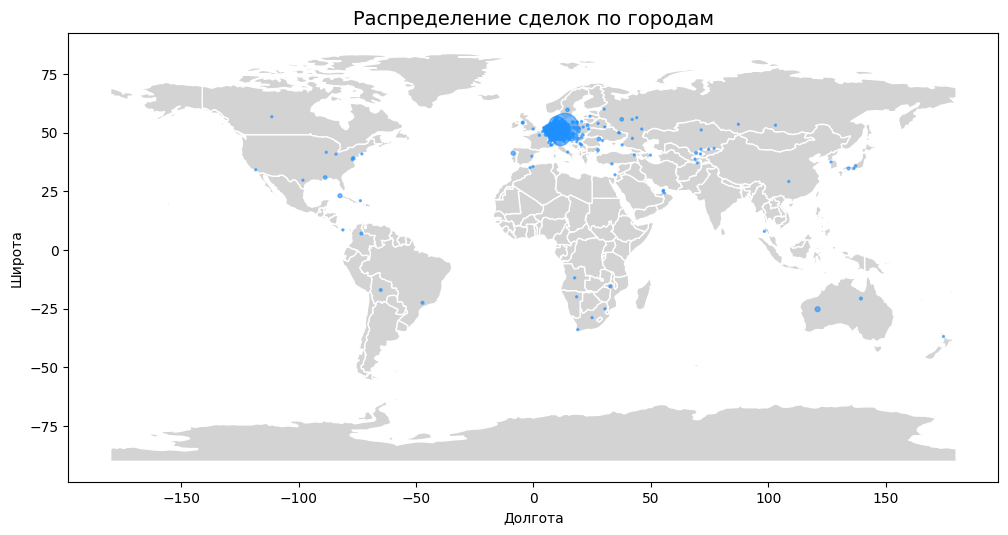

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# создаём геометрию точек по координатам
geometry = [Point(xy) for xy in zip(city_counts["Longitude"], city_counts["Latitude"])]
geo_gdf = gpd.GeoDataFrame(city_counts, geometry=geometry)

# загружаем карту мира
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)


# строим визуализацию
fig, ax = plt.subplots(figsize=(12, 8))
world.plot(ax=ax, color="lightgray", edgecolor="white")

# города — точки
geo_gdf.plot(
    ax=ax,
    markersize=geo_gdf["Deals_Count"] * 2,  # размер точки = количество сделок
    color="dodgerblue",
    alpha=0.6
)

plt.title("Распределение сделок по городам", fontsize=14)
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.show()


Интерактивная с Plotly

In [76]:
import plotly.express as px

fig3 = px.scatter_geo(
    city_counts,
    lat="Latitude",
    lon="Longitude",
    hover_name="City_final",     # город при наведении
    hover_data={"Deals_Count": True, "Latitude": False, "Longitude": False},  # показываем только количество
    size="Deals_Count",          # размер точки = количество сделок
    color="Deals_Count",         # цвет точки по количеству сделок
    color_continuous_scale="Viridis",
    projection="natural earth",
    title="📍 Геораспределение сделок по городам",
)

fig3.update_traces(marker=dict(line=dict(width=0)))  # убрать контуры у точек
fig3.update_layout(
    geo=dict(
        showland=True,
        landcolor="rgb(243, 243, 243)",
        showcountries=True,
        countrycolor="gray",
        showocean=True,
        oceancolor="azure"
    ),
)
fig3.show()


In [77]:
fig3.write_html("deals_cities.html")


In [78]:
# сохраняем интерактивный график в JSON
fig3.write_json("deals_cities.json")


2. Изучите влияние уровня знания немецкого языка на успешность сделок в
разных городах.

Шаг: очистка поля Level of Deutsch. Примерный-примерный вариант.

In [ ]:
import re

# шаблон для поиска уровней языка (учитывает кириллицу и латиницу)
pattern = r'([aаbвcс][0-2])'

def extract_deutsch_level(text):
    if not isinstance(text, str):
        return None
    match = re.search(pattern, text.lower())
    if match:
        level = match.group(1)
        # перевод кириллицы в латиницу
        level = (
            level.replace('а', 'a')
                 .replace('в', 'b')
                 .replace('с', 'c')
        )
        return level.upper()
    return None

# создаём новый столбец с очищенными уровнями
deals_geo["Deutsch_clean"] = deals_geo["Level of Deutsch"].apply(extract_deutsch_level)


In [ ]:
print(deals_geo["Deutsch_clean"].value_counts(dropna=False))


Deutsch_clean
None    18911
B1        583
A2        149
B2        114
C1         31
A1         25
A0          6
C2          3
Name: count, dtype: int64


In [ ]:
# Сохраняем очищенный датафрейм в новый Excel-файл
deals_geo.to_excel("Deals_geo_german.xlsx", index=False)

print("✅ Файл успешно сохранён как 'Deals_geo_german.xlsx'")

✅ Файл успешно сохранён как 'Deals_geo_german.xlsx'


Городов много, возьмем топ-10 городов по количеству сделок

In [ ]:
top_cities = deals_geo["City_final"].value_counts().head(10).index.tolist()
print("Топ-10 городов:", top_cities)


Топ-10 городов: ['Berlin', 'Ottobrunn bei München', 'Hamburg', 'Leipzig', 'Nürnberg', 'Düsseldorf', 'Dresden', 'Frankfurt am Main', 'Dortmund', 'Köln']


Отберём только “успешные” сделки

In [ ]:
mask = (deals_geo["City_final"].isin(top_cities)) & (deals_geo["Stage"] == "Payment Done")
effective_deals = deals_geo.loc[mask, ["City_final", "Deutsch_clean"]].dropna(subset=["Deutsch_clean"])


Посчитаем количество успешных сделок по уровням языка

In [ ]:
level_city_counts = (
    effective_deals.groupby(["City_final", "Deutsch_clean"])
    .size()
    .reset_index(name="Deals_Count")
)
level_city_counts.head()


,City_final,Deutsch_clean,Deals_Count
0,Berlin,A1,1
1,Berlin,A2,3
2,Berlin,B1,24
3,Berlin,B2,5
4,Berlin,C1,2


Преобразуем в удобную сводную таблицу

In [ ]:
level_city_pivot = (
    level_city_counts
    .pivot(index="City_final", columns="Deutsch_clean", values="Deals_Count")
    .fillna(0)
)
level_city_pivot


Deutsch_clean,A1,A2,B1,B2,C1
City_final,,,,,
Berlin,1.0,3.0,24.0,5.0,2.0
Dortmund,0.0,1.0,1.0,0.0,0.0
Dresden,0.0,1.0,2.0,0.0,0.0
Düsseldorf,0.0,0.0,2.0,1.0,0.0
Frankfurt am Main,0.0,1.0,0.0,0.0,0.0
Hamburg,0.0,1.0,2.0,1.0,0.0
Köln,0.0,2.0,0.0,0.0,0.0
Leipzig,0.0,2.0,4.0,0.0,0.0
Nürnberg,0.0,0.0,6.0,0.0,0.0


Визуализация — stacked bar chart

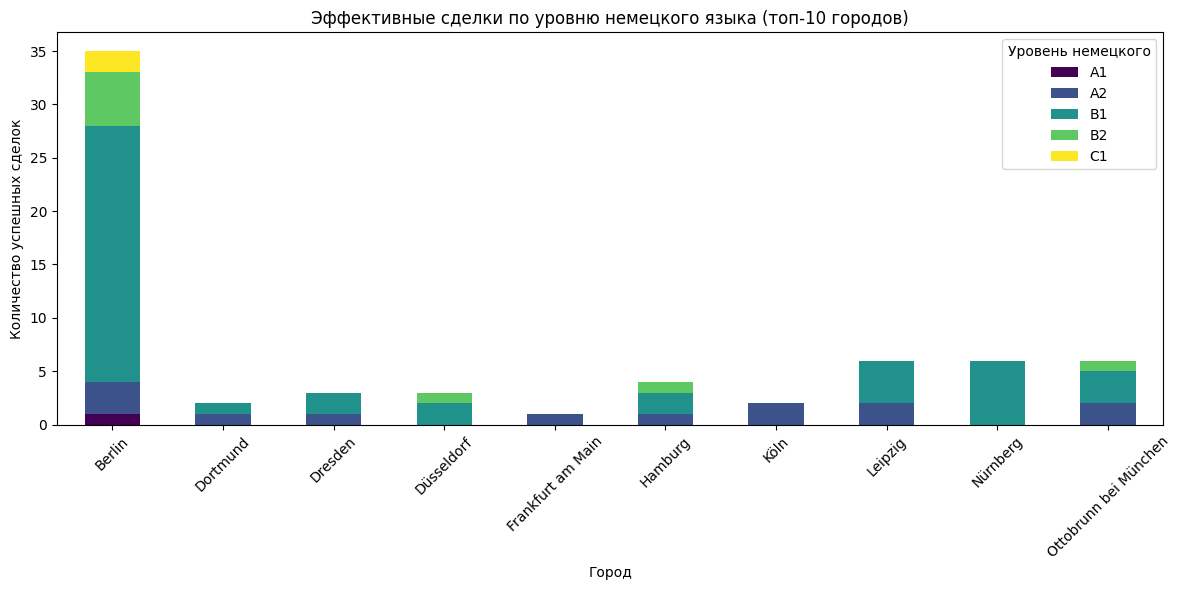

In [ ]:
import matplotlib.pyplot as plt

level_city_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="viridis"
)
plt.title("Эффективные сделки по уровню немецкого языка (топ-10 городов)")
plt.ylabel("Количество успешных сделок")
plt.xlabel("Город")
plt.legend(title="Уровень немецкого")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Plotly

In [ ]:
import plotly.express as px

fig = px.bar(
    level_city_counts,
    x="City_final",
    y="Deals_Count",
    color="Deutsch_clean",
    title="📊 Эффективные сделки по уровню немецкого языка в топ-10 городах",
    labels={"City_final": "Город", "Deals_Count": "Количество сделок", "Deutsch_clean": "Уровень немецкого"},
)
fig.update_layout(barmode="stack", xaxis_tickangle=-45)
fig.show()


Теперь неуспешные сделки

In [ ]:
mask2 = (deals_geo["City_final"].isin(top_cities)) & (deals_geo["Stage"] == "Lost")
non_effective_deals = deals_geo.loc[mask2, ["City_final", "Deutsch_clean"]].dropna(subset=["Deutsch_clean"])

In [ ]:
level_city_counts2 = (
    non_effective_deals.groupby(["City_final", "Deutsch_clean"])
    .size()
    .reset_index(name="Deals_Count2")
)
level_city_counts2.head()

,City_final,Deutsch_clean,Deals_Count2
0,Berlin,A1,1
1,Berlin,A2,7
2,Berlin,B1,13
3,Berlin,B2,4
4,Berlin,C1,1


In [ ]:
level_city_pivot2 = (
    level_city_counts2
    .pivot(index="City_final", columns="Deutsch_clean", values="Deals_Count2")
    .fillna(0)
)
level_city_pivot2

Deutsch_clean,A1,A2,B1,B2,C1
City_final,,,,,
Berlin,1.0,7.0,13.0,4.0,1.0
Dortmund,0.0,0.0,2.0,1.0,2.0
Dresden,0.0,1.0,0.0,1.0,0.0
Düsseldorf,0.0,0.0,5.0,2.0,2.0
Frankfurt am Main,0.0,0.0,3.0,0.0,0.0
Hamburg,0.0,2.0,8.0,2.0,1.0
Köln,0.0,1.0,3.0,0.0,0.0
Leipzig,0.0,1.0,7.0,0.0,0.0
Nürnberg,0.0,3.0,10.0,2.0,0.0


In [ ]:
fig2 = px.bar(
    level_city_counts2,
    x="City_final",
    y="Deals_Count2",
    color="Deutsch_clean",
    title="📊 Неэффективные сделки по уровню немецкого языка в топ-10 городах",
    labels={"City_final": "Город", "Deals_Count2": "Количество сделок", "Deutsch_clean": "Уровень немецкого"},
)
fig2.update_layout(barmode="stack", xaxis_tickangle=-45)
fig2.show()

Теперь проанализируем зависимость (сохранять базу с новым столбцом не буду). По всем городам.

In [ ]:
import numpy as np

# создаем новый столбец "is_success"
deals_geo["is_success"] = np.where(
    deals_geo["Stage"] == "Payment Done", 1,        # успешная сделка
    np.where(deals_geo["Stage"] == "Lost", 0, np.nan)  # неуспешная = 0, остальные NaN
)

# проверим распределение
print(deals_geo["is_success"].value_counts(dropna=False))


is_success
0.0    13997
NaN     4969
1.0      856
Name: count, dtype: int64


Отбираем только завершённые сделки

In [ ]:
deals_finished = deals_geo.dropna(subset=["is_success", "Deutsch_clean"]).copy()


Создаём таблицу сопряжённости

In [ ]:
contingency = pd.crosstab(deals_finished["Deutsch_clean"], deals_finished["is_success"])
print(contingency)


is_success     0.0  1.0
Deutsch_clean          
A0               2    4
A1              12    9
A2              81   44
B1             250  210
B2              68   23
C1              16   11
C2               0    1


χ²-тест независимости

In [ ]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi² = {chi2:.2f}")
print(f"p-value = {p:.5f}")


Chi² = 18.19
p-value = 0.00578


p-value < 0.05, → есть значимая связь между уровнем немецкого и успешностью сделок.

А какая именно связь?

Deutsch_clean
C2    1.000000
A0    0.666667
B1    0.456522
A1    0.428571
C1    0.407407
A2    0.352000
B2    0.252747
Name: is_success, dtype: float64


<Axes: title={'center': 'Доля успешных сделок по уровню немецкого'}, xlabel='Уровень немецкого', ylabel='Успешность (доля 1)'>

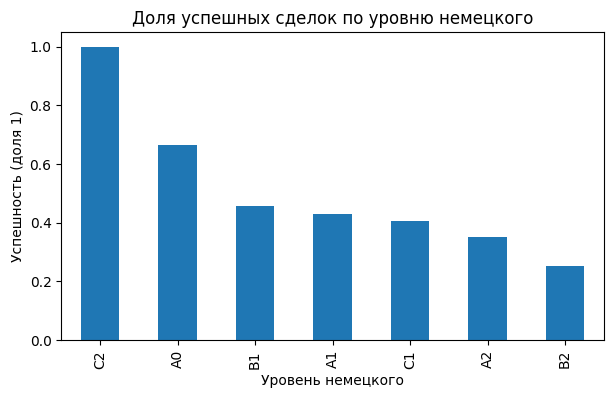

In [ ]:
# доля успешных сделок по каждому уровню языка
success_rate = (
    deals_finished.groupby("Deutsch_clean")["is_success"]
    .mean()
    .sort_values(ascending=False)
)
print(success_rate)

# визуализация
success_rate.plot(kind="bar", title="Доля успешных сделок по уровню немецкого", ylabel="Успешность (доля 1)", xlabel="Уровень немецкого", figsize=(7,4))


Теперь построим график успешности сделок по уровню немецкого только для Берлина 👇

In [ ]:
berlin_df = deals_finished[deals_finished["City_final"] == "Berlin"].copy()
print("Количество завершенных сделок в Берлине:", len(berlin_df))


Количество завершенных сделок в Берлине: 61


In [ ]:
berlin_success = (
    berlin_df.groupby("Deutsch_clean")["is_success"]
    .mean()
    .sort_values(ascending=False)
)
print(berlin_success)


Deutsch_clean
C1    0.666667
B1    0.648649
B2    0.555556
A1    0.500000
A2    0.300000
Name: is_success, dtype: float64


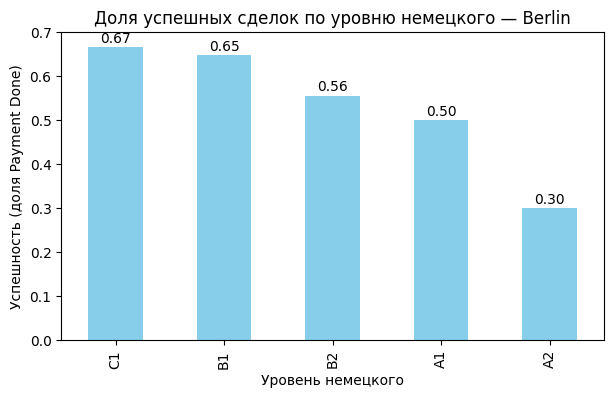

In [ ]:
ax = berlin_success.plot(
    kind="bar",
    color="skyblue",
    figsize=(7,4),
    title="Доля успешных сделок по уровню немецкого — Berlin",
    ylabel="Успешность (доля Payment Done)",
    xlabel="Уровень немецкого",
)

# добавим подписи значений на бары
for i, val in enumerate(berlin_success):
    ax.text(i, val + 0.01, f"{val:.2f}", ha='center')

plt.show()


И тоже для 5-и топ городов

In [ ]:
top5_cities = (
    deals_finished["City_final"]
    .value_counts()
    .head(5)
    .index
)
print("Топ-5 городов:", list(top5_cities))


Топ-5 городов: ['Berlin', 'Nürnberg', 'Hamburg', 'Leipzig', 'Ottobrunn bei München']


In [ ]:
top5_df = deals_finished[deals_finished["City_final"].isin(top5_cities)]


In [ ]:
city_lang_success = (
    top5_df.groupby(["City_final", "Deutsch_clean"])["is_success"]
    .mean()
    .reset_index()
)


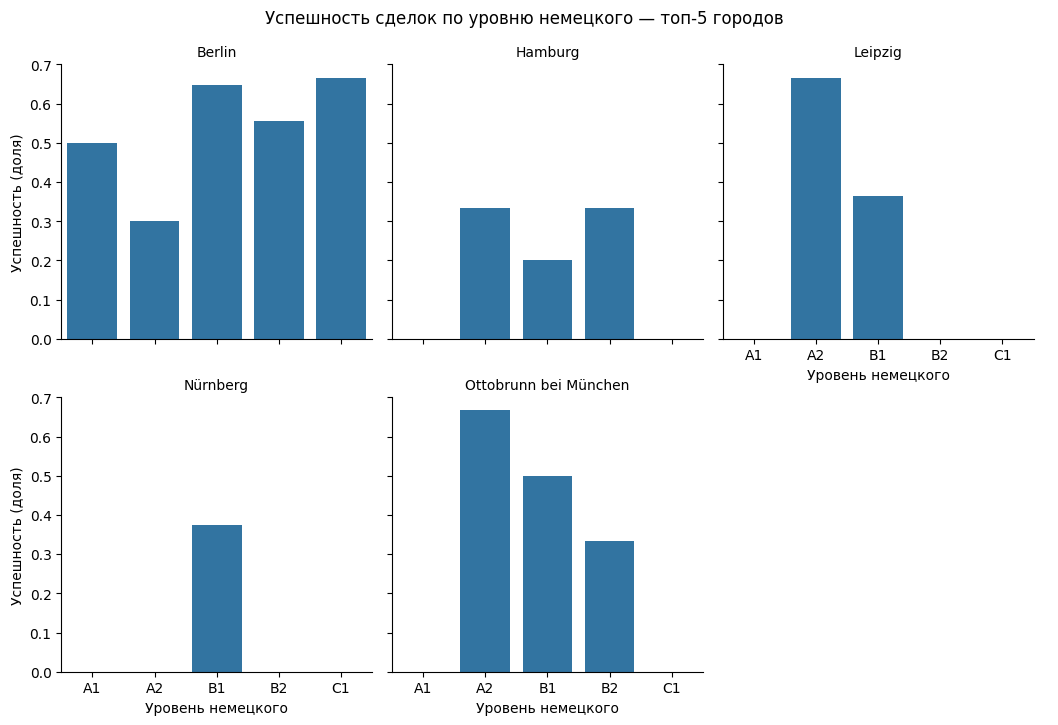

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=city_lang_success,
    x="Deutsch_clean",
    y="is_success",
    col="City_final",
    kind="bar",
    col_wrap=3,
    sharey=True,
    height=3.5,
)
g.set_titles("{col_name}")
g.set_axis_labels("Уровень немецкого", "Успешность (доля)")
g.fig.suptitle("Успешность сделок по уровню немецкого — топ-5 городов", y=1.03)
plt.show()


В Plotly. Хочу напомнить, что промежуточные стадии в расчет не брались, только Payment Done и Lost.

In [72]:
import plotly.express as px

# создаём временный столбец с долей в процентах
city_lang_success["is_success_pct"] = city_lang_success["is_success"] * 100

# интерактивный график
fig = px.bar(
    city_lang_success,
    x="Deutsch_clean",
    y="is_success_pct",
    color="Deutsch_clean",
    facet_col="City_final",
    facet_col_wrap=3,
    category_orders={"City_final": top5_cities},
    labels={"Deutsch_clean": "Уровень немецкого", "is_success_pct": "Успешность (%)"},
    title="Успешность сделок по уровню немецкого — топ-5 городов",
    hover_data={"Deutsch_clean": True, "is_success_pct": True, "City_final": False}  # убираем City_final из всплывающего
)

# убираем префикс City_final= из заголовков панелей
for annotation in fig.layout.annotations:
    if "=" in annotation.text:
        annotation.text = annotation.text.split("=")[1]

fig.update_layout(showlegend=False, height=500)
fig.show()


In [73]:
fig.write_html("deals_german_top5.html")


In [75]:
# сохраняем интерактивный график в JSON
fig.write_json("deals_german_top5.json")

